# Using Neural Networks

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import os
from collections import Counter
from tokenizers import Tokenizer, models, trainers, pre_tokenizers, decoders

# ------------------------------------------------------------
# 1. Download data (Tiny Shakespeare – classic starter dataset)
# ------------------------------------------------------------

In [2]:
!wget -q https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt -O input.txt

with open("input.txt", "r", encoding="utf-8") as f:
    text = f.read()

print(f"Dataset length: {len(text):,} characters")
print("First 300 chars:\n", text[:300])
print("-" * 60)

Dataset length: 1,115,394 characters
First 300 chars:
 First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us
------------------------------------------------------------


# ------------------------------------------------------------
# 2. Character-level (exactly what you already have)
# ------------------------------------------------------------

In [3]:
chars = sorted(list(set(text)))
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for ch, i in char_to_idx.items()}
vocab_size_char = len(chars)

print(f"Character vocab size: {vocab_size_char}")
print("Some characters:", chars[:20])

# Encode whole text as character indices
char_data = torch.tensor([char_to_idx[c] for c in text], dtype=torch.long)
print(f"Character sequence length: {len(char_data):,}")

Character vocab size: 65
Some characters: ['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G']
Character sequence length: 1,115,394


# ------------------------------------------------------------
# 3. Prepare data for MLP training
# ------------------------------------------------------------

In [4]:
def create_dataset(data, seq_length):
    """Create input-output pairs for training the MLP."""
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return torch.stack(X), torch.tensor(y)

seq_length = 5  # Length of the input sequence
X, y = create_dataset(char_data, seq_length)
print(f"Dataset created with {X.size(0)} samples.")
print(f"Sample input sequence (indices): {X[-5:-1]}")

Dataset created with 1115389 samples.
Sample input sequence (indices): tensor([[58,  1, 61, 39, 49],
        [ 1, 61, 39, 49, 47],
        [61, 39, 49, 47, 52],
        [39, 49, 47, 52, 45]])


# ------------------------------------------------------------
# 4. Define the MLP model
# ------------------------------------------------------------

In [5]:
class SimpleMLP(nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super(SimpleMLP, self).__init__()
        self.fc1 = nn.Linear(vocab_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# ------------------------------------------------------------
# 5. Train the MLP model
# ------------------------------------------------------------

In [6]:
def train_model(model, X, y, epochs=10, learning_rate=0.001):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    loss_fn = nn.CrossEntropyLoss()
    loss_history = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        
        # One-hot encode the input
        batch_size = X.size(0)
        one_hot_X = torch.zeros(batch_size, seq_length, vocab_size_char)
        for i in range(seq_length):
            one_hot_X[:, i, :] = F.one_hot(X[:, i], num_classes=vocab_size_char).float()
        
        # Reshape for the model
        one_hot_X = one_hot_X.view(batch_size, -1)  # Flatten the input
        output = model(one_hot_X)

        loss = loss_fn(output, y)
        loss.backward()
        optimizer.step()
        
        loss_history.append(loss.item())
        print(f"Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.4f}")

    return loss_history

# ------------------------------------------------------------
# 6. Experiment with different learning rates and model sizes
# ------------------------------------------------------------

Epoch [1/20], Loss: 5.7899
Epoch [2/20], Loss: 5.7765
Epoch [3/20], Loss: 5.7629
Epoch [4/20], Loss: 5.7490
Epoch [5/20], Loss: 5.7347
Epoch [6/20], Loss: 5.7196
Epoch [7/20], Loss: 5.7038
Epoch [8/20], Loss: 5.6869
Epoch [9/20], Loss: 5.6689
Epoch [10/20], Loss: 5.6496
Epoch [11/20], Loss: 5.6289
Epoch [12/20], Loss: 5.6066
Epoch [13/20], Loss: 5.5825
Epoch [14/20], Loss: 5.5566
Epoch [15/20], Loss: 5.5287
Epoch [16/20], Loss: 5.4988
Epoch [17/20], Loss: 5.4666
Epoch [18/20], Loss: 5.4321
Epoch [19/20], Loss: 5.3952
Epoch [20/20], Loss: 5.3559


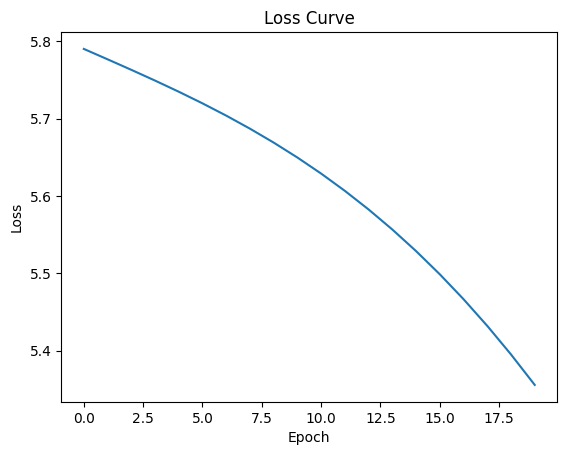

In [8]:
hidden_size = 128  # You can change this to see the effect
model = SimpleMLP(vocab_size_char * seq_length, hidden_size)

# Train the model
loss_history = train_model(model, X, y, epochs=20, learning_rate=0.001)

# Plotting the loss curve
import matplotlib.pyplot as plt

plt.plot(loss_history)
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# ------------------------------------------------------------
# 7. Generate text using the trained MLP
# ------------------------------------------------------------

In [13]:

def generate_text(model, start_str, length=100):
    model.eval()
    generated = list(start_str)
    input_seq = torch.tensor([char_to_idx[c] for c in start_str], dtype=torch.long).unsqueeze(0)

    for _ in range(length):
        # One-hot encode the input
        one_hot_input = F.one_hot(input_seq, num_classes=vocab_size_char).float()
        one_hot_input = one_hot_input.view(1, -1)  # Flatten the input for the model
        with torch.no_grad():
            output = model(one_hot_input)

        next_char_idx = torch.argmax(output[:, -1]).item()  # Get the predicted next character
        generated.append(idx_to_char[next_char_idx])
        
        # Update the input sequence
        input_seq = torch.cat((input_seq[:, 1:], torch.tensor([[next_char_idx]])), dim=1)

    return ''.join(generated)

# Generate text
generated_text = generate_text(model, start_str="A", length=200)
print("Generated text:\n", generated_text)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x65 and 325x128)